# Loss Functions — Illustrated

A **loss function** $L(y, \hat{y})$ measures how wrong a prediction $\hat{y}$ is relative to the true label $y$.
It converts the raw error of a single example into a scalar that the optimiser can minimise.

> The choice of loss encodes **what kinds of mistakes you can tolerate** — and how severely you want to penalise large ones.

---

## Two regimes, two error signals

### Regression — residual $r = y - \hat{y}$

The raw prediction error is the **residual**: how far the predicted value is from the true value.

$$r = y - \hat{y}$$

- $r > 0$ — prediction undershoots (model predicted too low)
- $r < 0$ — prediction overshoots (model predicted too high)
- $r = 0$ — perfect prediction

Different loss functions map the same residual to very different penalties:

| Loss | Formula | Tail behaviour | Outlier sensitivity |
|---|---|---|---|
| MSE | $r^2$ | Quadratic — grows without bound | Very high |
| MAE | $\|r\|$ | Linear | Low — robust |
| Huber ($\delta=1$) | $\frac{1}{2}r^2$ if $\|r\|\leq\delta$, else $\delta(\|r\|-\frac{\delta}{2})$ | Linear beyond $\delta$ | Medium |

### Classification — margin $m = y\,\hat{f}(x)$, where $y \in \{-1, +1\}$

For binary classification the useful quantity is not the raw prediction value but the **margin** — the product of the true label and the raw score:

$$m = y\,\hat{f}(x)$$

The sign of the margin tells you immediately whether the prediction is right or wrong:

- $m > 0$ — correct side: $y$ and $\hat{f}(x)$ have the same sign
- $m < 0$ — wrong side: misclassification
- $m = 1$ — correctly classified with confidence 1 (the SVM "safe zone" boundary)

The loss function maps the margin to a penalty. A good surrogate loss must:
1. Be large when $m < 0$ (punish mistakes)
2. Be **convex** (so gradient descent works)
3. Approximate the ideal 0-1 loss (which is non-differentiable and NP-hard to optimise directly)

---
## Regression Losses — Shapes and Influence

Each loss function is a different rule for converting a residual $r = y - \hat{y}$ into a penalty.
The *shape* of that penalty determines two things:

1. **What the fitted model optimises for** — MSE fits the conditional mean; MAE fits the conditional median.
2. **How much influence an outlier has** — determined by the gradient (right panel below).

The four losses below, in increasing order of robustness:

| Loss | Formula | Gradient $\partial L / \partial r$ |
|---|---|---|
| MSE | $r^2$ | $2r$ — grows with $r$, so outliers dominate |
| log-cosh | $\log(\cosh r)$ | $\tanh r$ — smoothly bounded |
| Huber ($\delta$) | $\frac{1}{2}r^2$ if $\|r\|\leq\delta$, else $\delta(\|r\|-\frac{\delta}{2})$ | $r$ or $\pm\delta$ — clipped at $\delta$ |
| MAE | $\|r\|$ | $\pm 1$ — constant influence regardless of residual size |

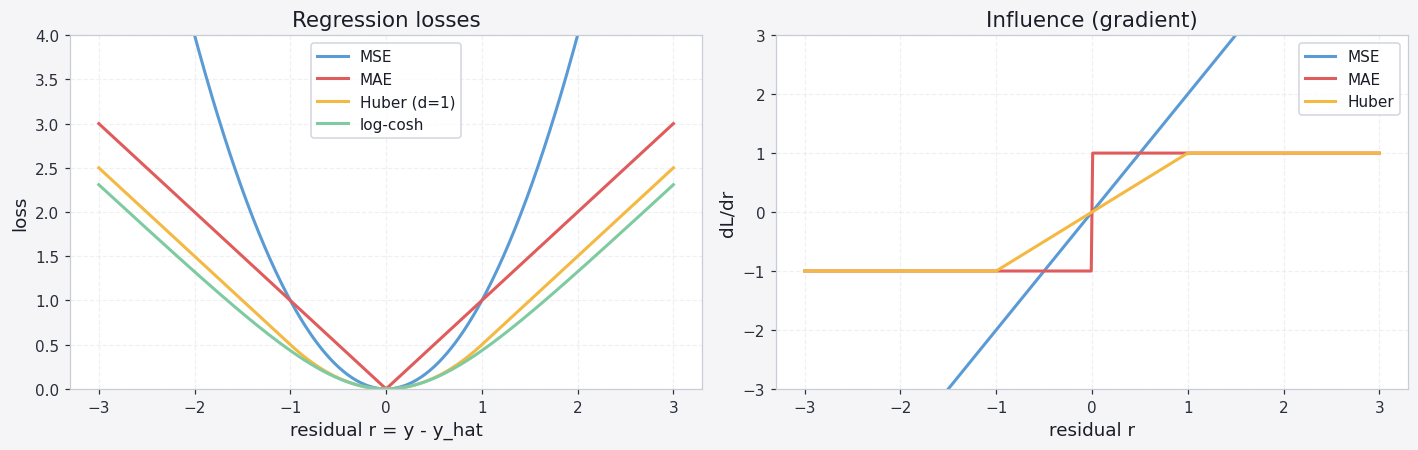

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

PLT_STYLE = {
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'xtick.labelsize':10,'ytick.labelsize':10,'legend.fontsize':10,'legend.facecolor':'#ffffff',
    'legend.edgecolor':'#c8ccd4','figure.dpi':110,
}
plt.rcParams.update(PLT_STYLE)
PALETTE = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']

r = np.linspace(-3, 3, 400)
def mse(r):   return r**2
def mae(r):   return np.abs(r)
def huber(r, d=1.0):
    a = np.abs(r); return np.where(a<=d, 0.5*r*r, d*(a-0.5*d))
def logcosh(r): return np.log(np.cosh(r))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
ax = axes[0]
ax.plot(r, mse(r),   color=PALETTE[0], lw=2, label='MSE')
ax.plot(r, mae(r),   color=PALETTE[1], lw=2, label='MAE')
ax.plot(r, huber(r), color=PALETTE[2], lw=2, label='Huber (d=1)')
ax.plot(r, logcosh(r), color=PALETTE[3], lw=2, label='log-cosh')
ax.set_xlabel('residual r = y - y_hat'); ax.set_ylabel('loss')
ax.set_title('Regression losses'); ax.legend(); ax.grid(True)
ax.set_ylim(0, 4)

# Gradients (the influence of an outlier on the fit)
def dmse(r): return 2*r
def dmae(r): return np.sign(r)
def dhuber(r, d=1.0):
    return np.where(np.abs(r)<=d, r, d*np.sign(r))
ax = axes[1]
ax.plot(r, dmse(r),   color=PALETTE[0], lw=2, label='MSE')
ax.plot(r, dmae(r),   color=PALETTE[1], lw=2, label='MAE')
ax.plot(r, dhuber(r), color=PALETTE[2], lw=2, label='Huber')
ax.set_xlabel('residual r'); ax.set_ylabel('dL/dr')
ax.set_title('Influence (gradient)'); ax.legend(); ax.grid(True)
ax.set_ylim(-3, 3)
plt.tight_layout(); plt.show()


---
## Robustness in action

Fit each loss to a clean dataset and a copy with 5 outliers.


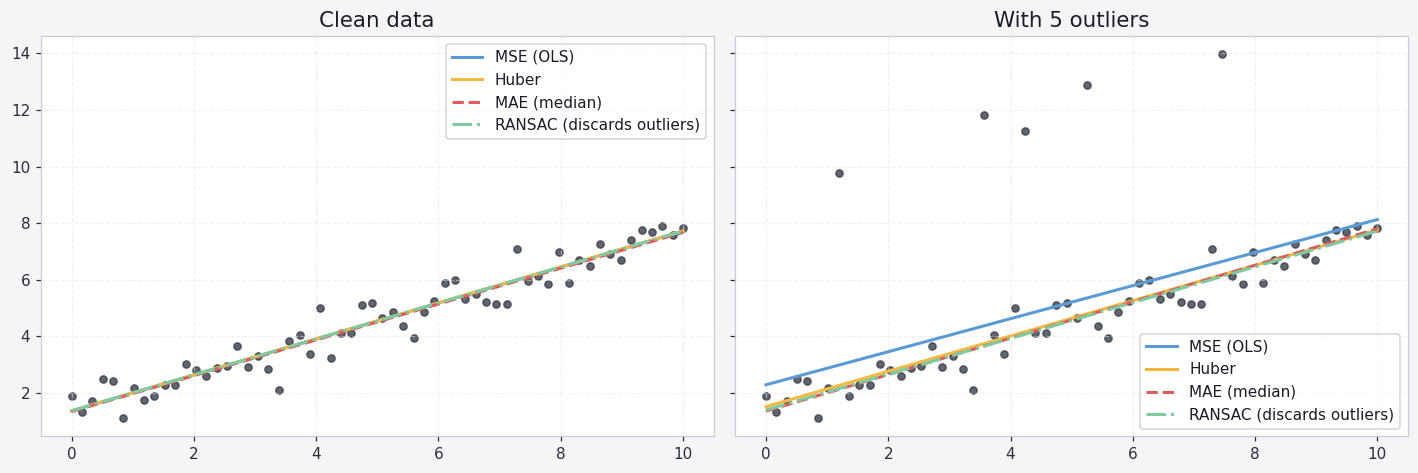

In [10]:
from sklearn.linear_model import LinearRegression, HuberRegressor
from sklearn.linear_model import QuantileRegressor, RANSACRegressor

rng = np.random.RandomState(0)
n = 60
x = np.linspace(0, 10, n)
y = 0.7*x + 1 + 0.5*rng.randn(n)
y_out = y.copy(); idx = rng.choice(n, 5, replace=False); y_out[idx] += 8

def fit(model, x, y):
    return model.fit(x[:, None], y).predict(x[:, None])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), sharey=True)
for ax, ydata, title in zip(axes, [y, y_out], ['Clean data', 'With 5 outliers']):
    ax.scatter(x, ydata, s=22, color='#3a3e4a', alpha=0.8)
    ax.plot(x, fit(LinearRegression(), x, ydata),  color=PALETTE[0], lw=2, label='MSE (OLS)')
    ax.plot(x, fit(HuberRegressor(), x, ydata),    color=PALETTE[2], lw=2, label='Huber')
    ax.plot(x, fit(QuantileRegressor(quantile=0.5, alpha=0), x, ydata),
            color=PALETTE[1], lw=2, ls='--', label='MAE (median)')
    ax.plot(x, fit(RANSACRegressor(random_state=0), x, ydata),
            color=PALETTE[3], lw=2, ls='-.', label='RANSAC (discards outliers)')
    ax.set_title(title); ax.grid(True); ax.legend()
plt.tight_layout(); plt.show()

---
## Classification Losses — Surrogate Losses on the Margin

Regression losses act on the residual $r = y - \hat{y}$.
For binary classification with $y \in \{-1, +1\}$ a residual is the wrong framing —
what matters is not the signed distance but whether the prediction is on the **correct side**.

The natural error signal is the **margin**:

$$m = y\,\hat{f}(x)$$

- $m > 0$ — correct side, larger $m$ means more confident
- $m < 0$ — wrong side (misclassification)

The ideal loss would be the 0-1 loss ($1$ if $m < 0$, else $0$), but it is non-convex and has zero gradient almost everywhere — gradient descent cannot optimise it.

Instead we use **convex surrogate losses** that upper-bound the 0-1 loss and have usable gradients:

| Loss | Formula | Used by | Property |
|---|---|---|---|
| Hinge | $\max(0, 1-m)$ | SVM | Zero loss for $m \geq 1$ — only errors matter |
| Logistic | $\log(1 + e^{-m})$ | Logistic regression | Always positive — gives calibrated probabilities |
| Exponential | $e^{-m}$ | AdaBoost | Up-weights mistakes aggressively |

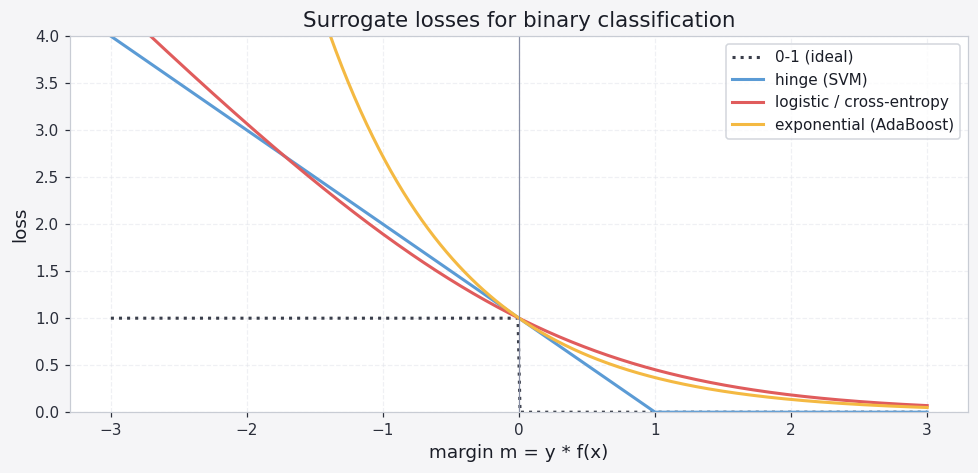

In [11]:
m = np.linspace(-3, 3, 400)

def zero_one_loss(m): return (m < 0).astype(float)
def hinge_loss(m):    return np.maximum(0, 1 - m)
def logistic_loss(m): return np.log1p(np.exp(-m)) / np.log(2)  # base-2 so it crosses 1 at m=0
def exp_loss(m):      return np.exp(-m)

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(m, zero_one_loss(m), color='#3a3e4a', lw=2, ls=':', label='0-1 (ideal)')
ax.plot(m, hinge_loss(m),    color=PALETTE[0], lw=2, label='hinge (SVM)')
ax.plot(m, logistic_loss(m), color=PALETTE[1], lw=2, label='logistic / cross-entropy')
ax.plot(m, exp_loss(m),      color=PALETTE[2], lw=2, label='exponential (AdaBoost)')
ax.axvline(0, color='#888fa5', lw=0.8); ax.set_xlabel('margin m = y * f(x)')
ax.set_ylabel('loss'); ax.set_ylim(0, 4)
ax.set_title('Surrogate losses for binary classification')
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

---
## When to use what

### Regression

| Situation | Recommended loss | Why |
|---|---|---|
| Clean data, need fast training | MSE | Smooth gradients, closed-form OLS solution |
| Outliers expected | Huber or MAE | Linear tail limits outlier influence |
| Need the conditional median | MAE / Quantile | MAE minimises the median, not the mean |
| Severe outliers, can discard them | RANSAC | Outliers excluded entirely before fitting |

### Classification

| Situation | Recommended loss | Why |
|---|---|---|
| Need calibrated probabilities | Cross-entropy (logistic) | Minimising it maximises log-likelihood |
| Maximum-margin boundary, sparse support | Hinge | Zero loss for correctly classified points |
| Boosting ensemble | Exponential | Up-weights hard examples each round |

> **Key insight**: the loss is not a technical detail — it defines *what your model is solving for*.
> MSE and MAE applied to the same data produce different fitted lines; cross-entropy and hinge produce different decision boundaries. Choose the loss that matches the cost structure of your problem.